In [43]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

SHARES = 1.4e9

def get_stock_history(ticker: str, start: str, end: str) -> pd.DataFrame:
    asset = yf.Ticker(ticker)
    df = asset.history(start=start, end=end)
    df.reset_index(inplace=True)
    return df


stock_df = get_stock_history("RY.TO", "2020-01-01", "2026-01-01")
stock_df["Date"] = pd.to_datetime(stock_df["Date"])
stock_df.set_index("Date", inplace=True)
stock_df.index = stock_df.index.tz_localize(None)
stock_df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2020-01-02,81.225295,81.500528,80.910742,81.429756,1354100,0.0,0.0
2020-01-03,80.910742,81.374710,80.729878,81.130928,3199000,0.0,0.0
2020-01-06,80.792777,81.162377,80.753462,81.146652,3139000,0.0,0.0
2020-01-07,81.351115,81.555575,81.091613,81.178116,1289100,0.0,0.0
2020-01-08,81.162374,82.184672,81.099462,81.822937,4035100,0.0,0.0
...,...,...,...,...,...,...,...
2025-12-23,231.516831,232.976473,231.506892,232.400558,1675900,0.0,0.0
2025-12-24,232.340978,233.323991,231.725337,232.201965,762300,0.0,0.0
2025-12-29,232.033154,234.257373,232.033154,233.522583,2141600,0.0,0.0


In [44]:
covered_bonds = [
    43674797950, 41170797950, 63030797950, 65326620450, 65326620450, 75326620450, 75326620450, 72596620450, 72596620450, 70316895450,70316895450, 68454520450,
    70387895450, 70387895450, 65845145450, 62787660450, 62787660450, 41496160450, 43880324450, 43880324450, 46870084450, 47930089450, 47930089450,47110039450,
    49952439450, 68948840892, 54857239450, 55193268392, 56554893392, 57293133392, 58811913392, 58811913392, 58936143392, 58936143392, 58976733392, 67476573392,
    68948840892, 68948840892, 64366479892, 69132297392, 69132297392, 67580242392, 69798742392, 69798742392, 66072092392, 66173368392, 66173368392, 70891968392,
    68238968392, 68238968392, 72286143392, 72286143392, 72286143392, 72396603392, 72396603392, 72396603392, 72396603392, 70761203392, 70761203392, 70761203392,
    68606953392, 70856953392, 69296953392, 69296953392, 67935328392, 65914688392, 65546408392, 65546408392, 63274208392, 70274208392,70274208392, 60661958392]

dates = pd.date_range(start="2020-01-01", end="2025-12-31", freq='MS')

# Create a DataFrame
df_covered_bonds = pd.DataFrame({
    "Month": dates,
    "Covered_Bonds": covered_bonds
})

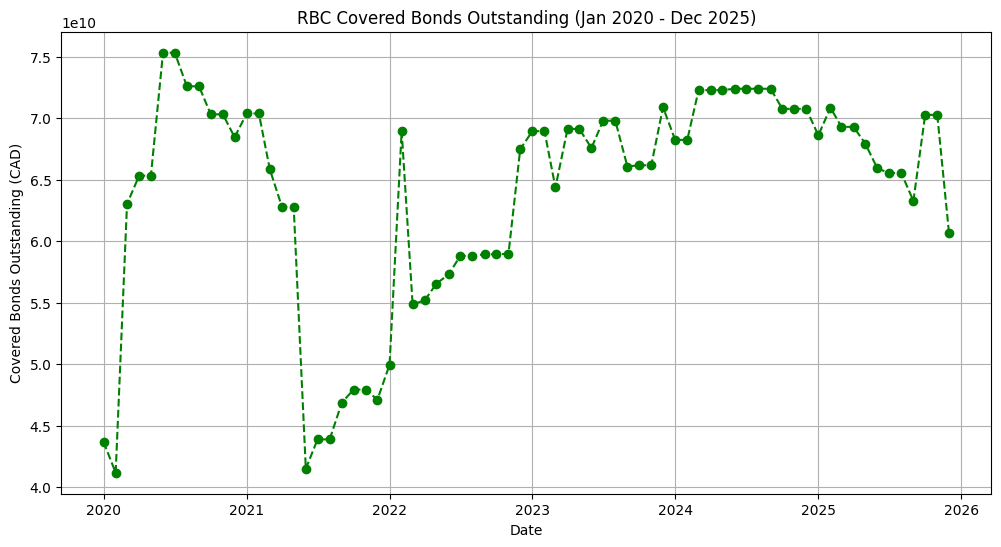

In [45]:
import matplotlib.pyplot as plt
import pandas as pd

dates_cb = pd.date_range(start="2020-01-01", end="2025-12-01", freq='MS')
df_covered_bonds = pd.DataFrame({"Month": dates_cb, "Covered_Bonds": covered_bonds})
df_covered_bonds.set_index("Month", inplace=True)

plt.figure(figsize=(12,6))
plt.plot(df_covered_bonds.index, df_covered_bonds['Covered_Bonds'], color='green', linestyle='--', marker='o')
plt.title("RBC Covered Bonds Outstanding (Jan 2020 - Dec 2025)")
plt.xlabel("Date")
plt.ylabel("Covered Bonds Outstanding (CAD)")
plt.grid(True)

plt.savefig("RBC_covered_bonds.png", dpi=300, bbox_inches='tight')

plt.show()

In [46]:
def prepare_data(stock_df, covered_bonds):

    stock_prices = stock_df["Close"]

    debt = pd.Series(covered_bonds)
    debt.index = pd.date_range(start="2020-01-01", periods=len(debt), freq="ME")

    stock_prices_monthly = stock_prices.resample("ME").last()

    return stock_prices_monthly, debt

In [47]:
def compute_equity_vol(stock_prices):

    log_returns = np.log(stock_prices / stock_prices.shift(1))

    sigma_E = log_returns.rolling(12).std() * np.sqrt(12)

    return sigma_E

In [48]:
def merton_solver(E, sigma_E, D, r=0.03, T=1):

    if E <= 0 or sigma_E <= 0 or D <= 0:
        return np.nan, np.nan

    def equations(x):
        V, sigma_V = x

        if V <= 0 or sigma_V <= 0:
            return [1e10, 1e10]

        d1 = (np.log(V/D) + (r + 0.5*sigma_V**2)*T) / (sigma_V*np.sqrt(T))
        d2 = d1 - sigma_V*np.sqrt(T)

        eq1 = V*norm.cdf(d1) - D*np.exp(-r*T)*norm.cdf(d2) - E
        eq2 = (V/E)*norm.cdf(d1)*sigma_V - sigma_E

        return [eq1, eq2]

    V0 = E + D
    sigma_V0 = sigma_E * 0.5

    try:
        V, sigma_V = fsolve(equations, [V0, sigma_V0], maxfev=5000)

        if V <= 0 or sigma_V <= 0:
            return np.nan, np.nan

        return V, sigma_V

    except:
        return np.nan, np.nan

In [49]:
def merton_default_probability(stock_prices, debt):

    sigma_E = compute_equity_vol(stock_prices)

    results = []

    for date in stock_prices.index:

        if pd.isna(sigma_E.loc[date]):
            continue
        E = stock_prices.loc[date] * SHARES
        D = debt.loc[:date].iloc[-1]
        sigmaE = sigma_E.loc[date]

        V, sigma_V = merton_solver(E, sigmaE, D)

        DD = (np.log(V/D) + (0.03 - 0.5*sigma_V**2)) / sigma_V

        PD = norm.cdf(-DD)

        results.append([date, V, sigma_V, DD, PD])

    df = pd.DataFrame(results, columns=["Date","Firm Value","Asset Vol","Distance to Default","PD_Merton"])
    df.set_index("Date", inplace=True)

    return df

In [50]:
def creditmetrics_pd(stock_prices, debt):

    log_returns = np.log(stock_prices / stock_prices.shift(1))

    mu = log_returns.rolling(12).mean() * 12
    sigma = log_returns.rolling(12).std() * np.sqrt(12)


    results = []

    for date in stock_prices.index:

        if pd.isna(mu.loc[date]):
            continue

        V = stock_prices.loc[date] * SHARES
        D = debt.loc[:date].iloc[-1]

        drift = mu.loc[date]
        vol = sigma.loc[date]

        z = (np.log(D/V) - (drift - 0.5*vol**2)) / vol

        PD = norm.cdf(z)

        results.append([date, PD])

    df = pd.DataFrame(results, columns=["Date","PD_CreditMetrics"])
    df.set_index("Date", inplace=True)

    return df

In [51]:
stock_prices, debt = prepare_data(stock_df, covered_bonds)

merton_pd = merton_default_probability(stock_prices, debt)
creditmetrics_pd = creditmetrics_pd(stock_prices, debt)

final_df = merton_pd.join(creditmetrics_pd)
final_df.tail()

,Firm Value,Asset Vol,Distance to Default,PD_Merton,PD_CreditMetrics
Date,,,,,
2025-08-31,3.389869e+11,0.124844,13.339948,6.777708e-41,1.645865e-27
2025-09-30,3.444259e+11,0.125751,13.649970,1.009811e-42,1.829579e-29
2025-10-31,3.538281e+11,0.123309,13.290245,1.318562e-40,1.128508e-26
2025-11-30,3.686608e+11,0.125398,13.394278,3.265409e-41,4.988681e-28
2025-12-31,3.841465e+11,0.134646,13.863371,5.279838e-44,1.367455e-36


In [52]:
def merton_default_probability_5yr(stock_prices, debt):

    sigma_E = compute_equity_vol(stock_prices)
    r = 0.03
    T = 5

    results = []

    for date in stock_prices.index:

        if pd.isna(sigma_E.loc[date]):
            continue

        E = stock_prices.loc[date] * SHARES
        D = debt.loc[:date].iloc[-1]

        sigmaE = sigma_E.loc[date]
        V, sigma_V = merton_solver(E, sigmaE, D, r=r, T=T)

        if np.isnan(V) or np.isnan(sigma_V):
            continue
        DD = (np.log(V/D) + (r - 0.5*sigma_V**2)*T) / (sigma_V*np.sqrt(T))
        PD_5yr = norm.cdf(-DD)

        results.append([date, V, sigma_V, DD, PD_5yr])

    df = pd.DataFrame(results,
                      columns=["Date","Firm Value","Asset Vol","Distance to Default (5Y)","PD_Merton_5yr"])

    df.set_index("Date", inplace=True)

    return df

In [53]:
merton_5yr = merton_default_probability_5yr(stock_prices, debt)

merton_5yr.tail()

,Firm Value,Asset Vol,Distance to Default (5Y),PD_Merton_5yr
Date,,,,
2025-08-31,3.317940e+11,0.127516,6.071214,6.347358e-10
2025-09-30,3.374823e+11,0.128306,6.214270,2.578190e-10
2025-10-31,3.461163e+11,0.126020,6.049429,7.267996e-10
2025-11-30,3.609491e+11,0.128043,6.095955,5.439302e-10
2025-12-31,3.774896e+11,0.136994,6.304721,1.443563e-10


In [54]:
def creditmetrics_pd_5yr(stock_prices, debt, horizon=5):
    log_returns = np.log(stock_prices / stock_prices.shift(1))
    mu = log_returns.rolling(12).mean() * 12
    sigma = log_returns.rolling(12).std() * np.sqrt(12)

    results = []

    for date in stock_prices.index:

        if pd.isna(mu.loc[date]) or pd.isna(sigma.loc[date]):
            continue
        V = stock_prices.loc[date] * SHARES
        D = debt.loc[:date].iloc[-1]
        drift = mu.loc[date]
        vol = sigma.loc[date]
        z = (np.log(D/V) - (drift - 0.5*vol**2) * horizon) / (vol * np.sqrt(horizon))
        PD_5yr = norm.cdf(z)
        results.append([date, PD_5yr])
    df = pd.DataFrame(results, columns=["Date","PD_CreditMetrics_5yr"])
    df.set_index("Date", inplace=True)

    return df

In [55]:
creditmetrics_5yr = creditmetrics_pd_5yr(stock_prices, debt)

creditmetrics_5yr.tail()

,PD_CreditMetrics_5yr
Date,
2025-08-31,4.632002e-14
2025-09-30,2.102492e-14
2025-10-31,1.081696e-13
2025-11-30,2.951293e-14
2025-12-31,1.271098e-20


In [56]:
horizons = [1,2,3,4,5]
latest_date = stock_prices.index[-1]

merton_pds = []
creditmetrics_pds = []

E = stock_prices.loc[latest_date] * SHARES
D = debt.loc[:latest_date].iloc[-1]

sigma_E = compute_equity_vol(stock_prices).loc[latest_date]

for T in horizons:
    V, sigma_V = merton_solver(E, sigma_E, D, r=0.03, T=T)
    if np.isnan(V):
        merton_pds.append(np.nan)
    else:
        DD = (np.log(V/D) + (0.03 - 0.5*sigma_V**2)*T) / (sigma_V*np.sqrt(T))
        merton_pds.append(norm.cdf(-DD))

    log_returns = np.log(stock_prices / stock_prices.shift(1))
    mu = log_returns.rolling(12).mean() * 12
    sigma = log_returns.rolling(12).std() * np.sqrt(12)

    drift = mu.loc[latest_date]
    vol = sigma.loc[latest_date]

    z = (np.log(D/E) - (drift - 0.5*vol**2) * T) / (vol * np.sqrt(T))
    creditmetrics_pds.append(norm.cdf(z))

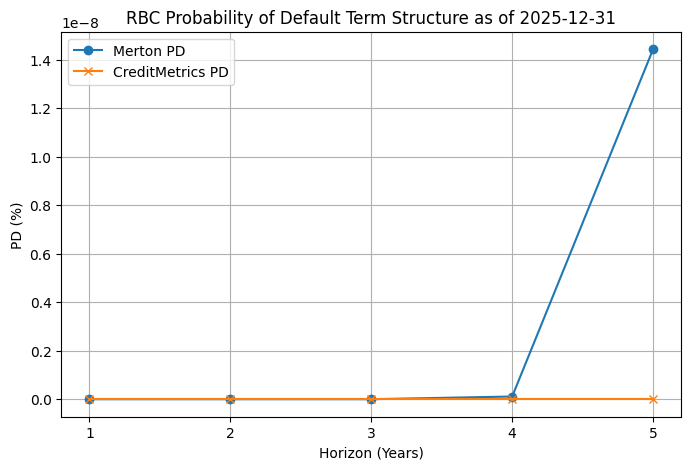

In [57]:
plt.figure(figsize=(8,5))
plt.plot(horizons, [p*100 for p in merton_pds], marker='o', label='Merton PD')
plt.plot(horizons, [p*100 for p in creditmetrics_pds], marker='x', label='CreditMetrics PD')
plt.title(f"RBC Probability of Default Term Structure as of {latest_date.date()}")
plt.xlabel("Horizon (Years)")
plt.ylabel("PD (%)")
plt.xticks(horizons)
plt.grid(True)
plt.legend()
plt.savefig("my_plot_tight.png", bbox_inches='tight')
plt.show()


In [58]:
def creditmetrics_transition(E, D, sigma_E, SHARES=1.4e9, r=0.03, horizon=5, n_sim=100000):
    np.random.seed(42)
    Z = np.random.normal(0,1,size=n_sim)
    V_T = E * np.exp((r - 0.5*sigma_E**2)*horizon + sigma_E*np.sqrt(horizon)*Z)

    bins = [0, D, 1.2*D, 1.5*D, 2*D, np.inf]
    labels = ['Default','BBB','A','AA','AAA']

    ratings = pd.cut(V_T, bins=bins, labels=labels, right=False)
    counts = ratings.value_counts().reindex(labels, fill_value=0)
    probs = counts / n_sim

    return probs

In [59]:
latest_date = stock_prices.index[-1]
E = stock_prices.loc[latest_date] * 1.4e9   # market cap
D = debt.loc[:latest_date].iloc[-1]         # latest debt
sigma_E = compute_equity_vol(stock_prices).loc[latest_date]

tmatrix_realistic_one = creditmetrics_transition(E, D, sigma_E,horizon= 1)
print(tmatrix_realistic_one)
tmatrix_realistic_thousand = creditmetrics_transition(E, D, sigma_E,horizon= 1000)
print(tmatrix_realistic_thousand)

Default    0.0
BBB        0.0
A          0.0
AA         0.0
AAA        1.0
Name: count, dtype: float64
Default    0.00009
BBB        0.00000
A          0.00002
AA         0.00003
AAA        0.99986
Name: count, dtype: float64


In [60]:
def compute_merton_kmv(stock_prices, shares_outstanding, debt, r=0.03, T=1):
    market_cap_series = stock_prices * shares_outstanding
    S = market_cap_series.iloc[-1]
    returns = market_cap_series.pct_change().dropna()
    sigma_S = returns.std() * np.sqrt(252)

    def equations(x):
        V, sigma_A = x
        d1 = (np.log(V / debt) + (r + 0.5 * sigma_A**2) * T) / (sigma_A * np.sqrt(T))
        d2 = d1 - sigma_A * np.sqrt(T)
        E_model = V * norm.cdf(d1) - debt * np.exp(-r*T) * norm.cdf(d2)
        sigma_S_model = norm.cdf(d1) * (V / S) * sigma_A
        return [E_model - S, sigma_S_model - sigma_S]

    V0 = S + debt
    sigma_A0 = sigma_S * (S / V0)


    V, sigma_A = fsolve(equations, [V0, sigma_A0])
    Leverage = debt / V
    DD = (np.log(V / debt) + (r - 0.5 * sigma_A**2) * T) / (sigma_A * np.sqrt(T))
    PD = 1 - norm.cdf(DD)

    return {
        'σ_S': sigma_S,
        'σ_A': sigma_A,
        'S': S,
        'L': debt,
        'Leverage': Leverage,
        'V': V,
        'Distance_to_Default': DD,
        'PD': PD
    }

In [61]:
ticker = yf.Ticker("RY.TO")
shares_outstanding = ticker.info["sharesOutstanding"]
total_debt = 6.07e10

metrics = compute_merton_kmv(stock_prices, shares_outstanding, total_debt)
print(metrics)

{'σ_S': np.float64(0.8288411643572656), 'σ_A': np.float64(0.7023305338835304), 'S': np.float64(323624356985.0579), 'L': 60700000000.0, 'Leverage': np.float64(0.15872979377281107), 'V': np.float64(382410879251.0593), 'Distance_to_Default': np.float64(2.312184598097165), 'PD': np.float64(0.010383756340979766)}


In [62]:
def creditmetrics_transition_matrix_absorbing(stock_prices, shares_outstanding, debt,
                                               sigma_E, r=0.03, horizon=1, n_sim=100000):
    states = ['D', 'BBB', 'A', 'AA', 'AAA']
    S = stock_prices.iloc[-1] * shares_outstanding


    V_current = S + debt

    sigma_A = sigma_E * (S / V_current)

    rating_start = {
        'AAA': V_current,
        'AA': 0.9 * V_current,
        'A': 0.75 * V_current,
        'BBB': 0.5 * V_current,
        'D': 0.3 * V_current
    }


    bins = [0, debt, 1.2*debt, 1.5*debt, 2*debt, np.inf]

    tmatrix = pd.DataFrame(index=states, columns=states)

    np.random.seed(42)

    for state, V0 in rating_start.items():
        if state == 'D':
            tmatrix.loc['D'] = [1.0, 0, 0, 0, 0]
            continue

        Z = np.random.normal(0, 1, n_sim)
        V_T = V0 * np.exp((r - 0.5 * sigma_A**2) * horizon +
                          sigma_A * np.sqrt(horizon) * Z)

        ratings = pd.cut(V_T, bins=bins, labels=states, right=False)

        counts = ratings.value_counts().reindex(states, fill_value=0)
        probs = counts / n_sim
        tmatrix.loc[state] = probs

    tmatrix.loc['D'] = [1.0, 0, 0, 0, 0]

    return tmatrix.astype(float)

In [63]:
returns = stock_prices.pct_change().dropna()
sigma_E = returns.std() * np.sqrt(252)

tmatrix = creditmetrics_transition_matrix_absorbing(
    stock_prices,
    shares_outstanding=1.4e9,
    debt=6.07e10,
    sigma_E=sigma_E,
    horizon=1,
    n_sim=100000
)

print(tmatrix)

           D      BBB        A       AA      AAA
D    1.00000  0.00000  0.00000  0.00000  0.00000
BBB  0.08790  0.05015  0.08356  0.13887  0.63952
A    0.02675  0.02059  0.04096  0.08486  0.82684
AA   0.01428  0.01286  0.02635  0.06187  0.88464
AAA  0.00984  0.00874  0.02074  0.04890  0.91178
